## Problem 5.3 - Performance for Polynomial Regression II

In [2]:
# mporting libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [3]:
# defining variables for the train data
n_values = np.round(np.power(10,np.linspace(1,5,10))).astype(int)
sigma = 0.3
k = 5
d = k + 1
np.random.seed(42)

In [4]:
# defining the function f(x)
def f(x):
    if (x.any() < -1 or x.any() > 1):
        print("cosh(x) is undefined")
        return NaN
    else:
        return np.cosh(x)

In [5]:
errors = []
for n in n_values:
    x = np.random.uniform(-1, 1, n)
    poly = PolynomialFeatures(degree = k)
    x_poly = poly.fit_transform(x.reshape(-1, 1))

    outer_risks = []
    for _ in range(100):
        y = f(x) + np.random.normal(0, sigma, n)
        model = LinearRegression(fit_intercept = False)
        model.fit(x_poly, y)
        y_pred = model.predict(x_poly)
        outer_risks.append(mean_squared_error(y, y_pred))
    estimated_lsr = np.mean(outer_risks)
    errors.append(estimated_lsr)

In [6]:
# calculate theorietical errors
theoretical_errors = [ ((n - d) / n)* sigma**2 for n in n_values ]

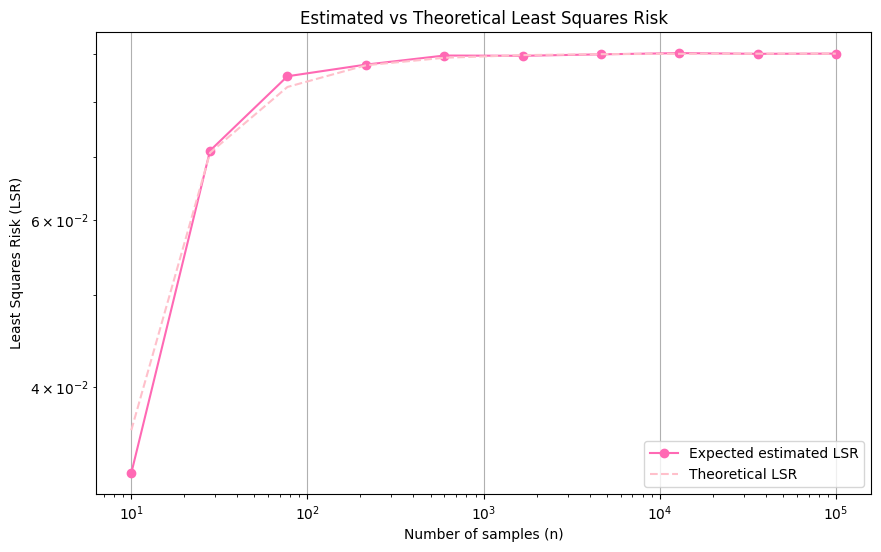

In [9]:
# plotting the results
plt.figure(figsize=(10, 6))
plt.loglog(n_values, errors, marker = 'o', label = 'Expected estimated LSR', color = 'hotpink')
plt.loglog(n_values, theoretical_errors, label = 'Theoretical LSR', color = 'pink', linestyle = '--')
plt.xlabel('Number of samples (n)')
plt.ylabel('Least Squares Risk (LSR)')
plt.title('Estimated vs Theoretical Least Squares Risk')
plt.legend()
plt.grid()
plt.show()